# 01 · 数据探索

**目标**：看清楚每个数据集长啥样，筛出可用样本。

本 notebook 用到（`scripts/download_data.py` 会一键拉下来）：
- `apoidea/pubtabnet-html`  → `data/raw/pubtabnet_sample/`  · 学术论文表格 (image + html)
- `ds4sd/FinTabNet_OTSL`   → `data/raw/fintabnet_sample/`  · 金融表格 (image + html + OTSL)
- `ByteDance/ComTQA`       → `data/raw/comtqa_sample/`    · 表格问答 (image_name + Q + A)
- `data/samples/*.pdf`     · 手工测试 PDF

> 💡 如果你之前拉过老版 `bsmock/pubtables-1m`（只有 XML annotation，没有图），先跑：
> ```bash
> uv run python scripts/download_data.py --clean-all
> uv run python scripts/download_data.py
> ```

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from src import config as C
from datasets import load_from_disk
print('RAW_DIR:', C.RAW_DIR)
print('子目录：', sorted(p.name for p in C.RAW_DIR.iterdir() if p.is_dir()))

RAW_DIR: /Users/pc-rn/ws/ai-lab/ocr-fine-app/data/raw
子目录： ['comtqa_sample', 'fintabnet_sample', 'pubtabnet_sample']


## 1. PubTabNet（学术论文表格 · image + html）

In [2]:
ds = load_from_disk(str(C.RAW_DIR / 'pubtabnet_sample'))
print(len(ds), 'rows')
print('features:', list(ds.features))
row = ds[0]
print('image type:', type(row.get('image')).__name__)
print('html (前 200 字):', (row.get('html') or '')[:200], '...')

500 rows
features: ['image', 'split', 'imgid', 'html', 'html_table']
image type: PngImageFile
html (前 200 字): {'cells': [{'tokens': ['<b>', 'K', 'i', 'n', 'e', 't', 'i', 'c', ' ', 'p', 'a', 'r', 'a', 'm', 'e', 't', 'e', 'r', '</b>'], 'bbox': [5, 9, 66, 19]}, {'tokens': ['<b>', 'N', 'D', '</b>'], 'bbox': [104, ...


### 1.1 看一张表格图 + HTML → Markdown 转换

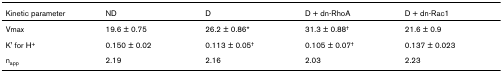

| ', ' | ', ' | ', ' | ', ' | ', ' |
|---|---|---|---|---|
| ', ' | ', ' | ', ' | ', ' | ', ' |
| ', ' | ', ' | ', ' | ', ' | ', ' |
| ', ' | ', ' | ', ' | ', ' | ', ' |


In [3]:
from src.data import html_table_to_markdown
sample = ds[0]
display(sample['image'])
md = html_table_to_markdown(sample.get('html') or sample.get('html_table'))
print(md[:800])

## 2. FinTabNet_OTSL（金融表格 · image + html list）

注意 FinTabNet_OTSL 的 `html` 字段是 **token 列表**（不是单个字符串），`html_table_to_markdown` 会自动处理两种形式。

300 rows
features: ['filename', 'split', 'imgid', 'dataset', 'cells', 'otsl', 'html', 'html_restored', 'cols', 'rows', 'html_len', 'otsl_len', 'image']
html type: list | otsl type: list


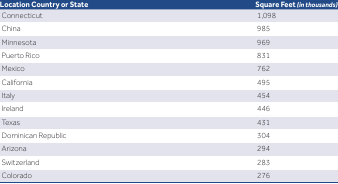

|  |  |
|---|---|
|  |  |
|  |  |
|  |  |
|  |  |
|  |  |
|  |  |
|  |  |
|  |  |
|  |  |
|  |  |
|  |  |
|  |  |
|  |  |


In [4]:
fin_dir = C.RAW_DIR / 'fintabnet_sample'
if fin_dir.exists():
    fin = load_from_disk(str(fin_dir))
    print(len(fin), 'rows')
    print('features:', list(fin.features))
    r0 = fin[0]
    print('html type:', type(r0['html']).__name__, '| otsl type:', type(r0.get('otsl')).__name__)
    display(r0['image'])
    print(html_table_to_markdown(r0['html'])[:600])
else:
    print('fintabnet_sample 未下载，跳过。')

## 3. ComTQA（表格问答）

ComTQA 只给 `image_name + question + answer`，**表格本身不在 row 里**。要当训练集用必须按 `image_name` 和 PubTab1M / FinTabNet 做 join（`dataset` 字段标明来自哪个源）。本教程默认走 PubTabNet / FinTabNet 的 html 自动生成模板 QA，ComTQA 留作后续扩展。

In [5]:
qa_dir = C.RAW_DIR / 'comtqa_sample'
if qa_dir.exists():
    qa_ds = load_from_disk(str(qa_dir))
    print(len(qa_ds), qa_ds.features)
    print(qa_ds[0])
    import collections
    print('来源分布:', collections.Counter(qa_ds['dataset']))
else:
    print('comtqa_sample 未下载，跳过。')

1000 {'image_name': Value('string'), 'question': Value('string'), 'answer': Value('string'), 'dataset': Value('string'), 'table_id': Value('string')}
{'image_name': 'PMC1079905_table_1.jpg', 'question': 'What is the third function of the vasa vasorum?', 'answer': 'Substrates of native LDL-cholesterol and modified LDL-cholesterol \n Substrates of phospholipids from systemic circulating cells', 'dataset': 'PubTab1M', 'table_id': None}
来源分布: Counter({'PubTab1M': 663, 'FinTabNet': 337})


## 4. 手工 PDF 的表格抽取

用 pdfplumber 先拿到 ground truth；后面 Stage 1 训练 VLM 学会从图片里做这件事。

In [6]:
from src.pdf_utils import pdf_to_images, extract_tables
pdfs = sorted(C.SAMPLES_DIR.glob('*.pdf'))
pdfs

[PosixPath('/Users/pc-rn/ws/ai-lab/ocr-fine-app/data/samples/apple_2023_q4.pdf'),
 PosixPath('/Users/pc-rn/ws/ai-lab/ocr-fine-app/data/samples/irs_form_1040.pdf')]

In [7]:
if pdfs:
    pdf = pdfs[0]
    imgs = pdf_to_images(pdf, C.DATA_DIR / 'preview' / pdf.stem)
    print(f'{len(imgs)} pages')
    tables = extract_tables(pdf)
    print(f'{len(tables)} tables')
    print(tables[0]['markdown'][:400] if tables else '无表格')
else:
    print('无样例 PDF。')

3 pages
3 tables
| Products | ! 67,184 |  | ! 70,958 |  | ! 298,085 |  | ! 316,199 |
|---|---|---|---|---|---|---|---|
| Services | 22,314 |  | 19,188 |  | 85,200 |  | 78,129 |
| Total net sales (1) | 89,498 |  | 90,146 |  | 383,285 |  | 394,328 |
| Cost of sales: |  |  |  |  |  |  |  |
| Products | 42,586 |  | 46,387 |  | 189,282 |  | 201,471 |
| Services | 6,485 |  | 5,664 |  | 24,855 |  | 22,075 |
| Total cost 


## 5. 构造训练集

运行脚本（会读上面的 `*_sample/` 目录，写出 jsonl）：

```bash
uv run python scripts/prepare_stage1.py
uv run python scripts/prepare_stage2.py
```

输出：
- `data/stage1_train/{train,val}.jsonl` · Stage 1 (VLM) sharegpt 格式
- `data/stage2_train/{train,val}.jsonl` · Stage 2 (LLM) alpaca 格式
- `data/stage1_images/*.png`              · Stage 1 的图片落盘


In [8]:
from src.data import load_jsonl
s1_p = C.DATA_DIR / 'stage1_train' / 'train.jsonl'
s2_p = C.DATA_DIR / 'stage2_train' / 'train.jsonl'
if s1_p.exists() and s2_p.exists():
    s1 = load_jsonl(s1_p); s2 = load_jsonl(s2_p)
    print(f'stage1={len(s1)}, stage2={len(s2)}')
    print('样例 stage1:', s1[0])
    print('样例 stage2:', s2[0])
else:
    print('还没构建训练集，先跑上面的 prepare_stage1/2 脚本。')

stage1=720, stage2=654
样例 stage1: {'messages': [{'role': 'user', 'content': [{'type': 'image', 'image': 'data/stage1_images/pubtabnet_00277.png'}, {'type': 'text', 'text': "请提取图中所有表格，以标准 Markdown 格式输出。如果没有表格，输出 '无表格'。"}]}, {'role': 'assistant', 'content': '| Genital micro-organisms | Prevalence of genital micro-organism in those with: |\n|---|---|\n|  | No lactobacilli |\n|  | n/N |\n| C trachomatis | 21/140 |\n| N gonorrhoeae | 12/138 |\n| Candida\n      \n      spp | 34/110 |\n| T vaginalis | 19/140 |\n| G vaginalis | 78/140 |\n| Anaerobes | 16/34 |\n| M hominis | 33/137 |'}]}
样例 stage2: {'instruction': '基于以下表格数据回答问题，引用具体数值与来源行。', 'input': '表格：\n| Parameter | Total | Disomy | Polysomy | Monosomy |\n|---|---|---|---|---|\n| Stage |  |  |  |  |\n| I | 39 | 36 | 3 | 0 |\n| II | 46 | 35 | 11 | 0 |\n| III | 35 | 28 | 5 | 2 |\n| IV | 7 | 6 | 0 | 1 |\n| Nodal status |  |  |  |  |\n| pN- | 35 | 29 | 5 | 1 |\n| pN+ | 113 | 99 | 12 | 2 |\n| HG |  |  |  |  |\n| I | 16 | 15 | 1 | 0 |\n| II | 55 